In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
print('libararies has been Imported seccussfully!')

libararies has been Imported seccussfully!


In [2]:
df = pd.read_csv('healthexp_statistics.csv')
df

,Unnamed: 0,Year,Country,Spending_USD,Life_Expectancy
0,0,1970,Germany,252.311,70.6
1,1,1970,France,192.143,72.2
2,2,1970,Great Britain,123.993,71.9
3,3,1970,Japan,150.437,72.0
4,4,1970,USA,326.961,70.9
...,...,...,...,...,...
269,269,2020,Germany,6938.983,81.1
270,270,2020,France,5468.418,82.3
271,271,2020,Great Britain,5018.700,80.4
272,272,2020,Japan,4665.641,84.7


## Phase 2 :

### 1. Determine which variables in the dataset are Discrete and Continuous :


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 274 entries, 0 to 273
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       274 non-null    int64  
 1   Year             274 non-null    int64  
 2   Country          274 non-null    object 
 3   Spending_USD     274 non-null    float64
 4   Life_Expectancy  274 non-null    float64
dtypes: float64(2), int64(2), object(1)
memory usage: 10.8+ KB


### Answer:
- **Discrete variable:** `Year` (integer, countable values)
- **Continuous variables:** `Spending_USD` and `Life_Expectancy` (float, can take any value in a range)
- **Categorical variable:** `Country` (nominal, non-numerical)
- `Unnamed: 0` is just an index and should be ignored or dropped.


### 2. Analyze the variable "Spending _USD" and State in a clear sentence what the average resulting from this analysis means (Note: be very precise, this is important)

In [4]:
total_capital = df["Spending_USD"].mean()
print (f"Total Capital is : {total_capital:.2f} $")

Total Capital is : 2789.34 $


The mean of Spending_USD across the entire dataset represents the average healthcare 
spending per capita, calculated across **all countries** and **all years (1970–2020)** combined. 
This value has limited meaning on its own because it aggregates very different countries 
(e.g., the USA spends significantly more than others) and very different time periods 
(spending was much lower in the 1970s than in the 2020s).

To make the average meaningful, we need to break it down using a pivot table, 
where each cell shows the mean spending per capita for a **specific country** in a **specific year**.


In [5]:
pivot = df.pivot_table(values='Spending_USD', columns='Year', index='Country', aggfunc='mean', fill_value = 0)
pivot


Year,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
Country,,,,,,,,,,,,,,,,,,,,,
Canada,0.000,313.391,0.000,0.000,0.000,0.000,543.337,0.000,0.000,692.269,...,4228.962,4336.249,4428.753,4536.810,4635.285,5044.275,5150.470,5308.356,5189.721,5828.324
France,192.143,0.000,0.000,0.000,0.000,363.610,0.000,0.000,0.000,0.000,...,4161.698,4299.434,4544.964,4626.679,4667.156,4928.128,5005.756,5099.306,5167.839,5468.418
Germany,252.311,298.251,337.364,384.541,452.744,532.481,591.098,647.352,729.457,800.703,...,4566.678,4745.546,4951.677,5151.709,5295.975,5669.064,5970.163,6281.840,6407.928,6938.983
Great Britain,123.993,134.172,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,3495.652,3614.131,3667.636,3758.935,3805.820,3960.141,4059.125,4189.708,4385.463,5018.700
Japan,150.437,163.854,185.390,205.778,242.018,284.269,303.725,340.628,392.577,452.931,...,3740.756,3970.765,4308.252,4328.364,4515.556,4295.858,4412.852,4554.276,4610.794,4665.641
USA,326.961,357.988,397.097,439.302,495.114,560.750,638.851,726.241,808.884,908.963,...,8079.467,8346.064,8519.620,8925.879,9355.118,9717.649,10046.472,10451.386,10855.517,11859.179


### 3. Create the two graphs needed for spending analysis :  

#### First graph represent the Mean capital by countries using the histogram :

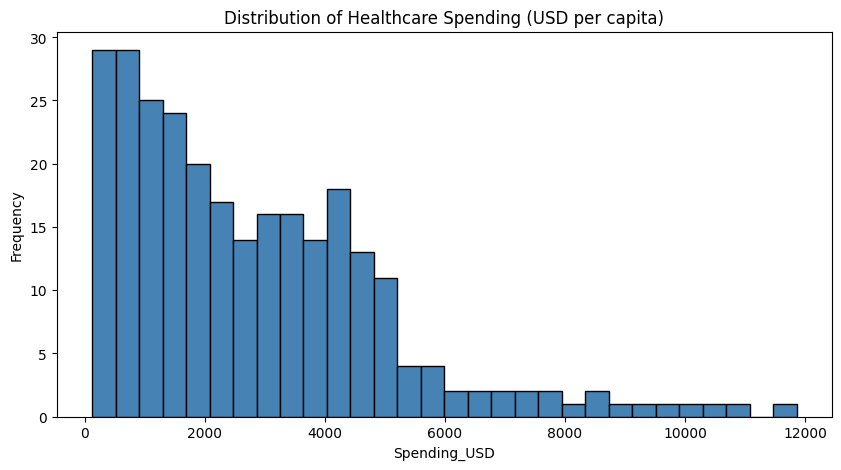

In [6]:
plt.figure(figsize=(10, 5))
plt.hist(df['Spending_USD'], bins=30, color='steelblue', edgecolor='black')
plt.title('Distribution of Healthcare Spending (USD per capita)')
plt.xlabel('Spending_USD')
plt.ylabel('Frequency')
plt.show()


#### Second Boxplot represent median and range spending by each Country :

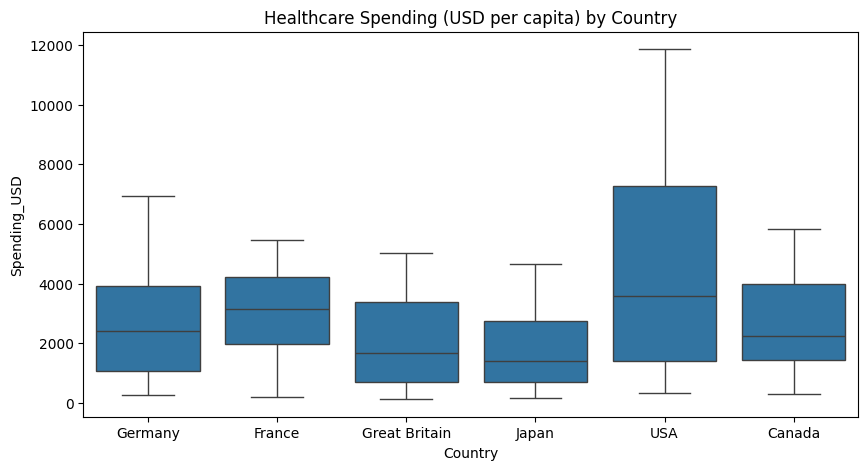

In [7]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='Country', y='Spending_USD', data=df)
plt.title('Healthcare Spending (USD per capita) by Country')
plt.xlabel('Country')
plt.ylabel('Spending_USD')
plt.show()


### 4. Create the two graphs needed for life expectancy analysis :  

#### First graph represent the Mean life expectancy by countries using the histogram :

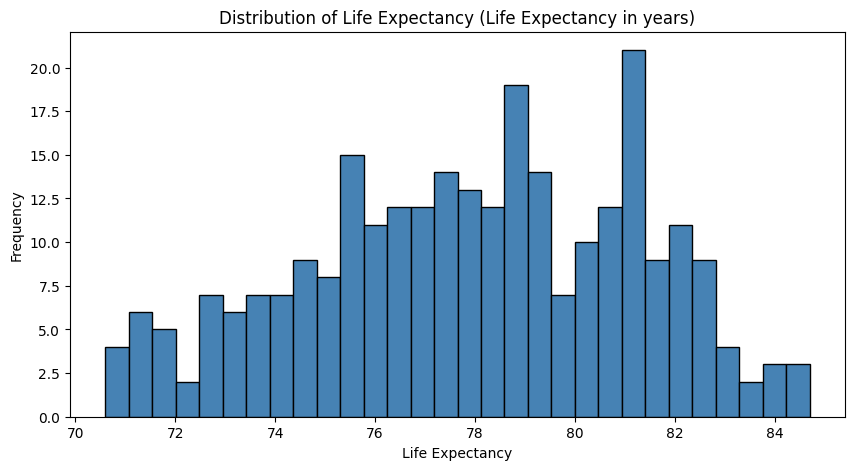

In [8]:
plt.figure(figsize=(10, 5))
plt.hist(df['Life_Expectancy'], bins=30, color='steelblue', edgecolor='black')
plt.title('Distribution of Life Expectancy (Life Expectancy in years)')
plt.xlabel('Life Expectancy')
plt.ylabel('Frequency')
plt.show()

#### third Boxplot represent median and range of Life Expectancy by each Country :

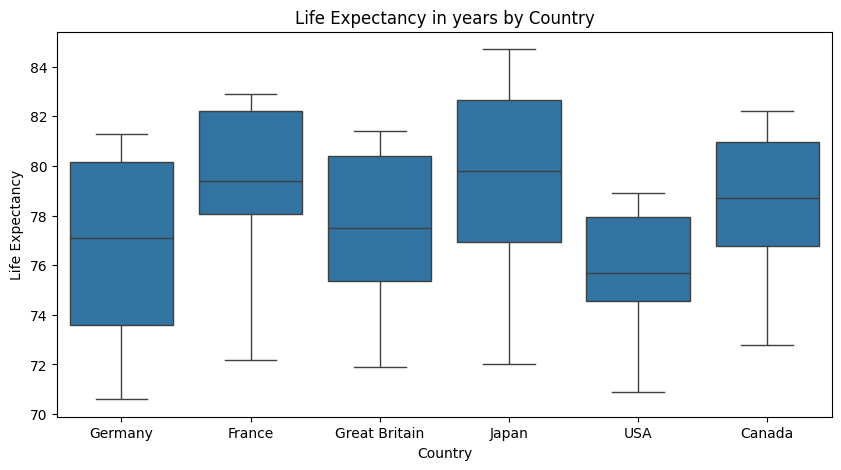

In [9]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='Country', y='Life_Expectancy', data=df)
plt.title('Life Expectancy in years by Country')
plt.xlabel('Country')
plt.ylabel('Life Expectancy')
plt.show()

### 5. Observe how lifespan changes over time :

#### first we are going to analyse the lifespan using the line chart to analyse the evolution :

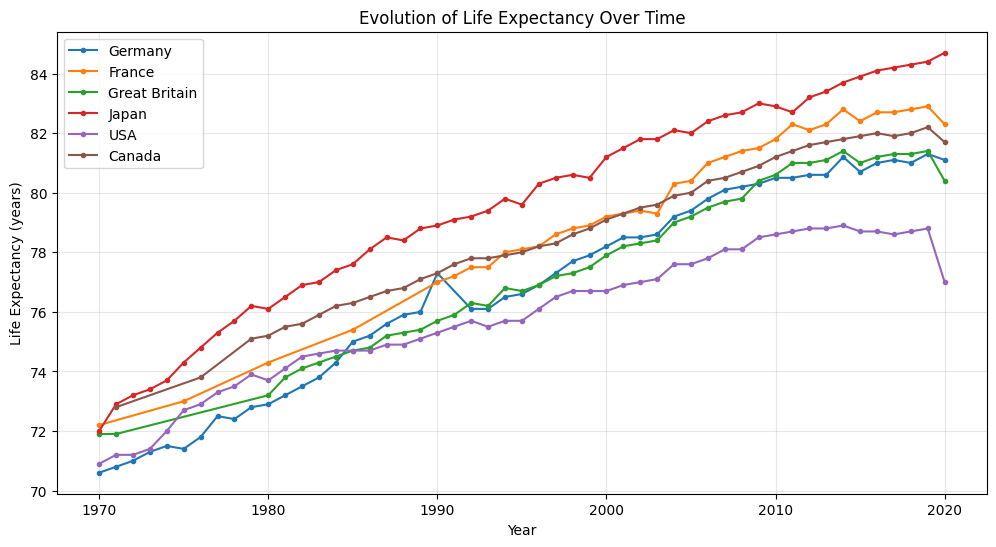

In [10]:
plt.figure(figsize=(12, 6))
for country in df['Country'].unique():
    country_data = df[df['Country'] == country]
    plt.plot(country_data['Year'], country_data['Life_Expectancy'], label=country, marker='o', markersize=3)

plt.title('Evolution of Life Expectancy Over Time')
plt.xlabel('Year')
plt.ylabel('Life Expectancy (years)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


#### second we are going to analyse the lifespan using boxplot to determinate the range and median in each decade :

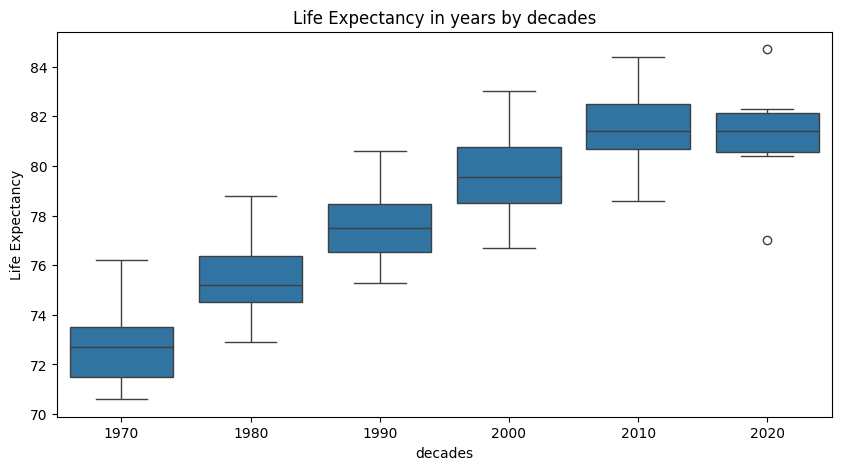

In [11]:
plt.figure(figsize=(10, 5))
df["decade"] = (df["Year"]//10)*10
sns.boxplot(x='decade', y='Life_Expectancy', data=df)
plt.title('Life Expectancy in years by decades')
plt.xlabel('decades')
plt.ylabel('Life Expectancy')
plt.show()


### 6. Observe the evolution of health spending in Germany and Great Britain over time :

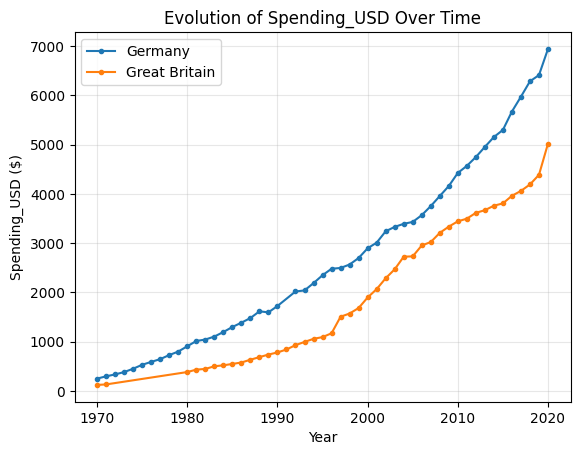

In [12]:
Countries_list = ["Germany", "Great Britain"]
for country in Countries_list:
    country_data = df[df['Country'] == country]
    plt.plot(country_data['Year'], country_data['Spending_USD'], label=country, marker='o', markersize=3)

plt.title('Evolution of Spending_USD Over Time')
plt.xlabel('Year')
plt.ylabel('Spending_USD ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### 7. Observe the relationship between life expectancy and healthcare spending in the United States from 2000 to 2020 :

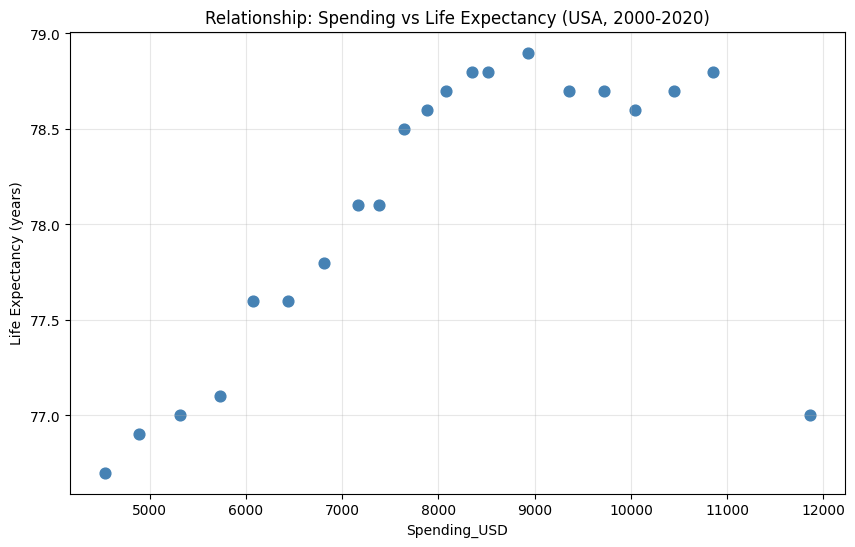

In [13]:
usa = df[(df['Country'] == 'USA') & (df['Year'] >= 2000) & (df['Year'] <= 2020)]

plt.figure(figsize=(10, 6))
plt.scatter(usa['Spending_USD'], usa['Life_Expectancy'], color='steelblue', s=60)
plt.title('Relationship: Spending vs Life Expectancy (USA, 2000-2020)')
plt.xlabel('Spending_USD')
plt.ylabel('Life Expectancy (years)')
plt.grid(True, alpha=0.3)
plt.show()


#### - There is an aberrant value in all of this. What is it? Why?

**The outlier:** The data point for **USA in 2020** (Spending: $11,859 / Life Expectancy: 77.0 years) 
is clearly aberrant. While all other points follow a general upward trend (more spending → longer life), 
this point shows the **highest spending ever recorded but a sharp drop in life expectancy** 
(from 78.8 to 77.0 years).

**Why?** The COVID-19 pandemic caused both a surge in healthcare spending (hospitalizations, 
emergency care, vaccines) and a significant increase in mortality, resulting in a lower average 
life expectancy despite record spending.

**Key takeaway — Correlation does not imply Causation:**
This outlier perfectly illustrates a fundamental principle in statistics: just because two variables 
are correlated does not mean one causes the other. The scatter plot shows a positive correlation 
between spending and life expectancy, but spending more money does not automatically cause people 
to live longer. External factors (like a pandemic) can completely break the pattern.

Even beyond COVID-19, the USA is an outlier throughout the entire dataset — it consistently 
spends 2 to 3 times more than other countries, yet has a lower life expectancy than Japan, 
France, or Canada. This suggests that other factors play a crucial role in determining life 
expectancy: diet and lifestyle, universal healthcare access, income inequality, 
and public health policies — none of which are captured by spending alone.

and to make sure that the covid 19 was the cause in this abberant results in 2020, we will make a chart that visuals the relationship between lifespan and spending 

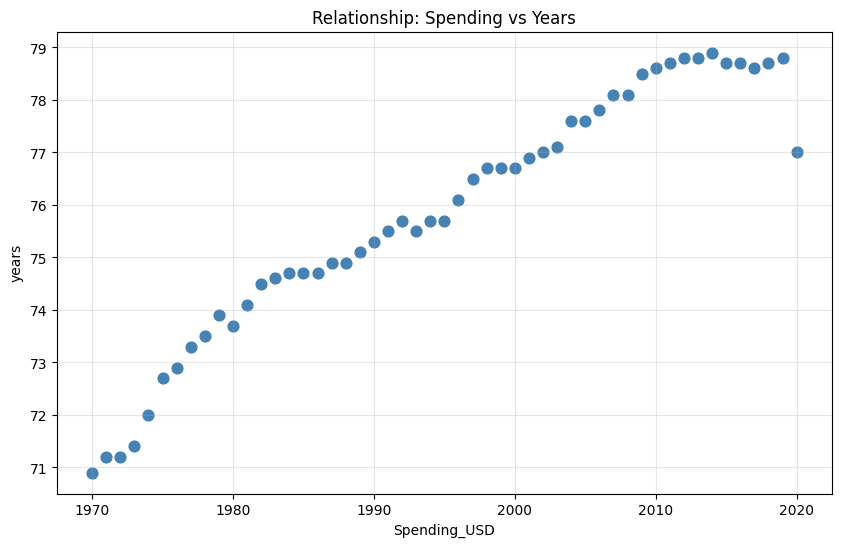

In [14]:
usa = df[(df['Country'] == 'USA')]

plt.figure(figsize=(10, 6))
plt.scatter(usa['Year'], usa['Life_Expectancy'], color='steelblue', s=60)
plt.title('Relationship: Spending vs Years')
plt.xlabel('Spending_USD')
plt.ylabel('years')
plt.grid(True, alpha=0.3)
plt.show()


here we confirm that in 2020 there is an obvious dropdown in lifespan, which we can say that the pandamic was the cause 

### 8. Calculate the Pearson correlation between these two variables in the United States (2000–2020) and  What is the probability (p-value) of obtaining a correlation at least as high if the two variables were independent? :


*Pearson Explained :*
The Pearson Correlation Coefficient ($r$) is a metric used to quantify the strength and direction of the linear relationship between two variables (e.g., Health Spending and Life Expectancy).High $r$ value (Strong): If the coefficient is close to $+1$ or $-1$, the relationship is strong. This suggests that one variable is a reliable predictor of the other, providing a solid foundation for data-driven insights and strategic decisions.Low $r$ value (Weak): If the coefficient tends toward $0$, the linear relationship is weak. In this case, we cannot rely on this correlation alone to support our insights. A weak correlation indicates that other external factors (confounding variables) or non-linear causes are likely driving the events, requiring a deeper multivariable analysis.

*P-Value Explained :*
The **P-value** is a metric used to determine whether the observed correlation between two variables (e.g., Health Spending and Life Expectancy) is **statistically significant** or simply the result of **random chance**. It works by testing a "null hypothesis" — the assumption that there is no real relationship between the two variables.

**Low P-value (< 0.05 — Significant):** If the P-value is below the threshold of $0.05$ (also called $\alpha$), we reject the null hypothesis. This means the observed correlation is very unlikely to have occurred by random chance, and the relationship between the two variables is considered **real and statistically significant**. In this case, we can confidently rely on the Pearson $r$ coefficient to assess the strength of that relationship.

**High P-value (≥ 0.05 — Not Significant):** If the P-value is above $0.05$, we cannot reject the null hypothesis. This means the observed correlation **could easily be the result of random chance**, and we do not have enough evidence to confirm that the relationship is real. In this case, even if the Pearson $r$ shows a moderate or strong value, we cannot trust it as a reliable indicator.

**Important note:** A low P-value does not "prove" that the relationship is real — it only suggests that the probability of it being random is very low. Similarly, **statistical significance does not imply causation**: other external factors (confounding variables) may be the true drivers behind the observed pattern.


In [15]:
# Calculation
usa = df[(df['Country'] == 'USA') & (df['Year'] >= 2000) & (df['Year'] <= 2020)]
r, p_value = stats.pearsonr(usa['Spending_USD'], usa['Life_Expectancy'])

# insights and results interpretations :
# --- Step 1: P-value → Is the relationship REAL? ---
if p_value < 0.05:
    print(f"→ P-value = {p_value:.6f} < alpha = 0.05")
    print("Which means:")
    print("- The correlation is statistically significant")
    print("- It is very unlikely to be random chance")
    print("- This suggests the relationship between Spending and Life Expectancy is real")
else:
    print(f"→ P-value = {p_value:.6f} >= alpha = 0.05")
    print("Which means:")
    print("- The correlation is NOT statistically significant")
    print("- It could easily be random chance")
    print("- We can't prove the relationship is real")

# --- Step 2: r → How STRONG is that relationship? ---
print()
abs_r = abs(r)
direction = "positive" if r > 0 else "negative"

if abs_r > 0.7:
    print(f"→ Pearson r = {r:.4f} → Strong {direction} correlation")
    print("Which means:")
    print("- The two variables are strongly linked")
    print("- When Spending goes up, Life Expectancy reliably goes up too" if r > 0 
          else "- When Spending goes up, Life Expectancy reliably goes down")
elif abs_r > 0.4:
    print(f"→ Pearson r = {r:.4f} → Moderate {direction} correlation")
    print("Which means:")
    print("- The two variables have a noticeable relationship, but it's not perfect")
    print("- Other external factors also influence Life Expectancy beyond just Spending")
else:
    print(f"→ Pearson r = {r:.4f} → Weak {direction} correlation")
    print("Which means:")
    print("- The linear relationship between the two variables is weak")
    print("- Spending alone cannot reliably predict Life Expectancy")

→ P-value = 0.002658 < alpha = 0.05
Which means:
- The correlation is statistically significant
- It is very unlikely to be random chance
- This suggests the relationship between Spending and Life Expectancy is real

→ Pearson r = 0.6211 → Moderate positive correlation
Which means:
- The two variables have a noticeable relationship, but it's not perfect
- Other external factors also influence Life Expectancy beyond just Spending


In [16]:

usa_data = df[(df['Country'] == 'USA') & (df['Year'] >= 1970)].copy()
usa_data = usa_data.sort_values(by='Year')

# Calculate the yearly change using .diff()
# We use dropna() to remove the first year (1970) because it has no previous year to subtract from
yearly_changes = usa_data['Life_Expectancy'].diff().dropna()


sample_mean = yearly_changes.mean()
print(f"Actual average yearly increase in our data: {sample_mean:.4f} years")


claimed_mean = 0.3
t_score, p_value = stats.ttest_1samp(yearly_changes, popmean=claimed_mean)

print(f"T-score calculated: {t_score:.4f}")
print(f"P-value calculated: {p_value:.6f}")


alpha = 0.02
print(f"\n--- Conclusion (Alpha = {alpha} / 98% Confidence) ---")

if p_value < alpha:
    print(f"P-value ({p_value:.6f}) < Alpha ({alpha})")
    print("Decision: REJECT the null hypothesis (H0).")
    print("Interpretation: We have strong evidence that the politician is WRONG.")
    print("The real average increase is statistically significantly different from 0.3 years.")
else:
    print(f"P-value ({p_value:.6f}) >= Alpha ({alpha})")
    print("Decision: FAIL TO REJECT the null hypothesis (H0).")
    print("Interpretation: The data does NOT contradict the politician.")
    print("We don't have enough evidence to say they are wrong, so the claim stands.")


Actual average yearly increase in our data: 0.1220 years
T-score calculated: -3.7212
P-value calculated: 0.000511

--- Conclusion (Alpha = 0.02 / 98% Confidence) ---
P-value (0.000511) < Alpha (0.02)
Decision: REJECT the null hypothesis (H0).
Interpretation: We have strong evidence that the politician is WRONG.
The real average increase is statistically significantly different from 0.3 years.
